# Generate and evaluate ranked molecular readouts

Evaluate spot-level gene-ranking recovery and gene-level spatial recovery on five held-out spatial transcriptomics slides.

## Installation

Create a Python 3.10+ environment, install the public HistAgent package and add
the lightweight analysis dependencies used by these notebooks.

```bash
git clone https://github.com/zipging/HistAgent.git
cd HistAgent
python -m venv .venv
source .venv/bin/activate
python -m pip install -e .
python -m pip install jupyter numpy pandas matplotlib seaborn scipy scikit-learn torch huggingface-hub
```

If `data/` is absent, the notebook downloads its data from
`wli13/HistAgent-data`. These examples run without a GPU. Running HistAgent on
new images requires access to the gated Prov-GigaPath model and an authenticated
Hugging Face session.

## Setup

Import the analysis packages, locate the tutorial data and set the plotting style.

In [1]:
from pathlib import Path
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

configured_data = os.getenv("HISTAGENT_TUTORIAL_DATA", "").strip()
DATA_DIR = Path(configured_data).expanduser() if configured_data else Path("data")
if not DATA_DIR.exists():
    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=["tutorials/**", "manifest.json"],
        )
    )
    DATA_DIR = snapshot / "tutorials"
assert DATA_DIR.exists(), f"Tutorial data not found: {DATA_DIR}"

def rankridge_pack_root(groups):
    configured = os.getenv("HISTAGENT_RANKRIDGE_PACKS", "").strip()
    if configured:
        root = Path(configured).expanduser()
        if not (root / groups[0]).exists():
            root = root / "rankridge_tutorial_packs"
        assert (root / groups[0]).exists(), f"RankRidge pack not found: {root}"
        return root

    from huggingface_hub import snapshot_download

    snapshot = Path(
        snapshot_download(
            "wli13/HistAgent-data",
            repo_type="dataset",
            allow_patterns=[
                f"rankridge_tutorial_packs/{group}/**" for group in groups
            ],
        )
    )
    return snapshot / "rankridge_tutorial_packs"

sns.set_theme(style="white", context="talk")
plt.rcParams.update({
    "figure.dpi": 135,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#000000",
    "axes.labelcolor": "#000000",
    "axes.linewidth": 1.25,
    "axes.grid": False,
    "xtick.color": "#000000",
    "ytick.color": "#000000",
    "text.color": "#000000",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 12,
})
COLORS = {
    "HistAgent": "#168267",
    "Measured ST": "#6f7477",
    "STPath": "#cb77a0",
    "OmiCLIP": "#69aec7",
}
SURVIVAL_COLORS = {"High risk": "#ef4545", "Low risk": "#45b3c2"}
REGION_COLORS = {
    "Poor": "#d85f6b",
    "High": "#79a9d1",
    "Negative": "#b7b7b7",
    "Tumor": "#e32925",
    "Stroma": "#62acec",
}
TASK_CMAPS = {
    "svg": "YlGnBu",
    "domain": "tab10",
    "deconv": "Greens",
    "deg": "Purples",
    "pathway": "PuBuGn",
}

## Overview

Five held-out slides cover human and mouse stomach, breast, lung, spleen and kidney tissue. HitRate@50 and mAP@50 use every evaluated spot. The spatial maps show one representative gene per slide, with PCC reported for the displayed measured and predicted fields.

In [2]:
rank = pd.read_csv(DATA_DIR / "figure3b_rank_metrics_per_section.csv")
maps = np.load(DATA_DIR / "quickstart_expression_maps.npz")
meta = json.loads((DATA_DIR / "quickstart_expression_maps.json").read_text())

selected = list(meta["sections"])
section_groups = {
    "GSE251950_GSM7990478": "human__stomach",
    "GSE213688_GSM6592052": "human__breast",
    "GSE202322_GSM6108350": "mouse__lung",
    "GSE254652_GSM8047883": "mouse__spleen",
    "GSE175540_GSM5924038": "human__kidney",
}
PACK_DIR = rankridge_pack_root(list(section_groups.values()))

from scipy import sparse
from scipy.spatial import cKDTree

def spatial_graph(coords, neighbors=6):
    coords = np.asarray(coords, dtype=float)
    k = min(neighbors, len(coords) - 1)
    _, indices = cKDTree(coords).query(coords, k=k + 1)
    rows = np.repeat(np.arange(len(coords)), k)
    columns = indices[:, 1:].reshape(-1)
    graph = sparse.csr_matrix(
        (np.ones(len(rows), dtype=np.float32), (rows, columns)),
        shape=(len(coords), len(coords)),
    )
    graph = graph.maximum(graph.T).tocsr()
    degree = np.asarray(graph.sum(axis=1)).ravel()
    inverse = np.divide(
        1.0, degree, out=np.zeros_like(degree), where=degree > 0
    )
    return (sparse.diags(inverse) @ graph).tocsr()

inferred_maps = {}
spatial_pcc = {}
for section in selected:
    pack = PACK_DIR / section_groups[section]
    x_query = sparse.load_npz(pack / "query_rank_features.npz").tocsr()
    coefficients = np.load(pack / "ridge_coefficients.npy")
    target_genes = (pack / "target_genes.txt").read_text().splitlines()
    feature_genes = (pack / "feature_genes.txt").read_text().splitlines()
    manifest = json.loads((pack / "pack_manifest.json").read_text())

    gene = meta["sections"][section]["gene"].upper()
    target_index = {g.upper(): i for i, g in enumerate(target_genes)}[gene]
    feature_index = {g.upper(): i for i, g in enumerate(feature_genes)}[gene]
    inferred = np.asarray(x_query @ coefficients)[:, target_index]
    if manifest["output_transform"] == "clip":
        inferred = np.maximum(inferred, 0)

    # The downstream maps retain inferred amplitude where the gene occurs in
    # the generated top 50, then apply the paper's six-neighbor smoothing.
    support = np.asarray(x_query[:, feature_index].toarray()).ravel() > 0
    inferred = inferred * support
    graph = spatial_graph(maps[f"{section}__coords"])
    inferred = (0.75 * inferred + 0.25 * (graph @ inferred)).astype(np.float32)
    measured = maps[f"{section}__measured"]
    assert len(inferred) == len(measured)
    inferred_maps[section] = inferred
    spatial_pcc[section] = float(np.corrcoef(measured, inferred)[0, 1])

rank5 = rank.query("section in @selected and method == 'HistAgent'").copy()
summary = rank5.copy()
summary["tissue"] = summary["section"].map(
    lambda s: f"{meta['sections'][s]['species']} {meta['sections'][s]['organ']}"
)
summary["PCC"] = summary["section"].map(
    spatial_pcc
)
summary = summary.rename(columns={
    "hit_rate_top50": "HitRate@50",
    "ap_top50": "mAP@50",
})
summary[
    ["section", "tissue", "HitRate@50", "mAP@50", "PCC"]
].round(3)

,section,tissue,HitRate@50,mAP@50,PCC
48,GSE213688_GSM6592052,human breast,0.575,0.514,0.745
90,GSE175540_GSM5924038,human kidney,0.739,0.706,0.731
222,GSE251950_GSM7990478,human stomach,0.657,0.593,0.753
345,GSE202322_GSM6108350,mouse lung,0.688,0.643,0.851
399,GSE254652_GSM8047883,mouse spleen,0.810,0.789,0.871


## Spot-level gene-ranking recovery

HitRate@50 is the fraction of measured top-50 genes recovered by the predicted top 50. Average precision also rewards correct genes that appear earlier in the prediction.

In [3]:
example_section = selected[0]
example = meta["rank_examples"][example_section]
truth = set(example["measured_top50"])
predicted = example["predicted_top50"]

hits = np.array([gene in truth for gene in predicted], dtype=float)
hit_rate = hits.sum() / 50
ap_at_50 = sum(
    hits[i] * hits[: i + 1].mean() for i in range(len(hits))
) / 50

check = pd.DataFrame({
    "rank": np.arange(1, 11),
    "predicted_gene": predicted[:10],
    "present_in_measured_top50": hits[:10].astype(bool),
})
print(f"Section: {example_section}")
print(f"Spot: {example['barcode']}")
print(f"Recalculated HitRate@50: {hit_rate:.3f}")
print(f"Recalculated AP@50: {ap_at_50:.3f}")
check

Section: GSE251950_GSM7990478
Spot: GSE251950_GSM7990478_ATATCGTTCCTCGAAC-1
Recalculated HitRate@50: 0.780
Recalculated AP@50: 0.703


,rank,predicted_gene,present_in_measured_top50
0,1,MYL9,True
1,2,TAGLN,True
2,3,DES,True
3,4,FLNA,True
4,5,ACTA2,True
5,6,TPM2,True
6,7,ACTG2,True
7,8,MYLK,False
8,9,CNN1,False
9,10,FTL,True


## Gene-level spatial recovery

HistAgent directly generates a top-50 gene ranking, not a continuous expression matrix. The code above downloads compact reference-derived mappers and evaluates the held-out rank-feature matrices with `X_query @ coefficients`. The displayed fields then use the same top-50 support and spatial smoothing as the downstream analysis.

Each gene pair shares its 2nd-98th percentile color scale, and PCC is calculated from the unscaled spot values produced in this notebook.

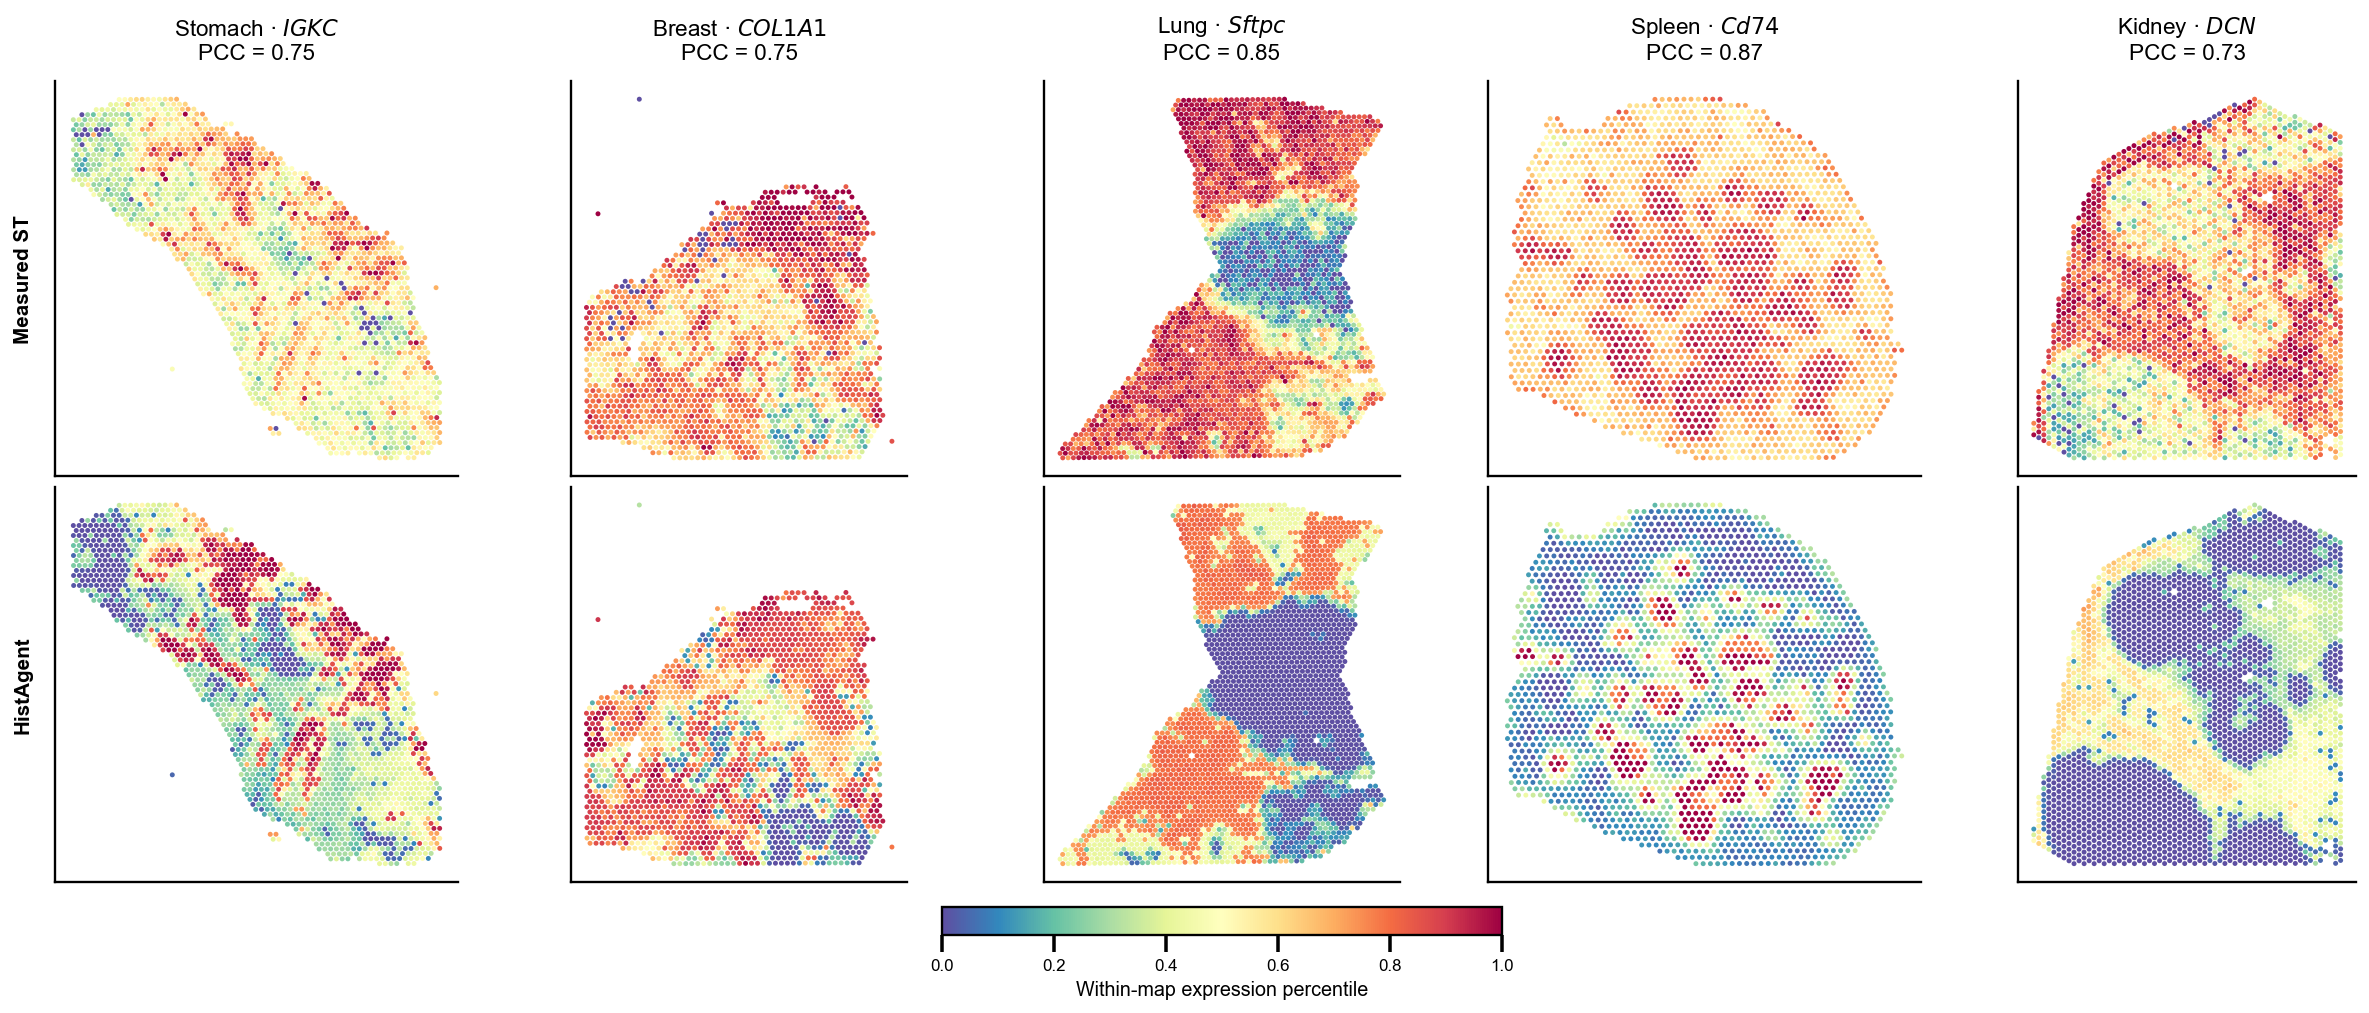

In [4]:
fig, axes = plt.subplots(
    2, len(selected), figsize=(18, 7.4), constrained_layout=True
)

for col, section in enumerate(selected):
    info = meta["sections"][section]
    xy = maps[f"{section}__coords"]
    measured = maps[f"{section}__measured"]
    predicted = inferred_maps[section]
    lo, hi = np.nanpercentile(np.r_[measured, predicted], [2, 98])
    scale = max(hi - lo, np.finfo(float).eps)
    for row, (label, values) in enumerate([
        ("Measured ST", measured), ("HistAgent", predicted)
    ]):
        ax = axes[row, col]
        normalized = np.clip((values - lo) / scale, 0, 1)
        sc = ax.scatter(
            xy[:, 0], xy[:, 1], c=normalized, s=7, cmap="Spectral_r",
            vmin=0, vmax=1, linewidths=0
        )
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            gene_label = info["gene"].replace("-", r"{-}")
            ax.set_title(
                f"{info['organ'].title()} · "
                + rf"$\mathit{{{gene_label}}}$"
                + f"\nPCC = {spatial_pcc[section]:.2f}",
                pad=12,
            )
        if col == 0:
            ax.set_ylabel(label, fontsize=11, fontweight="bold", labelpad=12)

fig.colorbar(
    sc, ax=axes, orientation="horizontal", fraction=0.035, pad=0.03,
    label="Within-map expression percentile"
)

plt.show()

## Verify the calculations

The checks below recompute the spot-level ranking example and verify the five displayed sections.

In [5]:
assert np.isclose(hit_rate, example["spot_hit_rate_at_50"])
assert np.isclose(ap_at_50, example["spot_ap_at_50"])
assert len(summary) == 5
assert summary["n_spots"].min() > 2_000
print("Checks passed for five sections and the worked ranking example.")

Checks passed for five sections and the worked ranking example.


## Continue

Continue to **Spatial biological findings** to recover and interpret a TLS-like immune niche in renal cell carcinoma.